![JohnSnowLabs](https://nlp.johnsnowlabs.com/assets/images/logo.png)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/JohnSnowLabs/spark-nlp-workshop/blob/master/tutorials/Certification_Trainings/Healthcare/5.3.Spark_OCR_Utility_Module.ipynb)

If you are using the `johnsnowlabs` library, please use this  [09.3.Spark_OCR_Utility_Module](https://github.com/JohnSnowLabs/spark-nlp-workshop/blob/master/healthcare-nlp/09.3.Spark_OCR_Utility_Module.ipynb) notebook.

# Setup

In [ ]:
import json
import os

from google.colab import files

if 'spark_jsl.json' not in os.listdir():
  license_keys = files.upload()
  os.rename(list(license_keys.keys())[0], 'spark_jsl.json')

with open('spark_jsl.json') as f:
    license_keys = json.load(f)

# Defining license key-value pairs as local variables
locals().update(license_keys)
os.environ.update(license_keys)

In [2]:
license_keys.keys()

dict_keys(['SPARK_NLP_LICENSE', 'SECRET', 'JSL_VERSION', 'SPARK_OCR_LICENSE', 'SPARK_OCR_SECRET', 'OCR_VERSION', 'PUBLIC_VERSION', 'AWS_ACCESS_KEY_ID', 'AWS_SECRET_ACCESS_KEY', 'AWS_SESSION_TOKEN'])

In [ ]:
# Installing Spark OCR
! pip install --upgrade -q spark-ocr==$OCR_VERSION --extra-index-url=https://pypi.johnsnowlabs.com/$SPARK_OCR_SECRET

# Installing pyspark and spark-nlp
! pip install --upgrade -q pyspark==3.4.0 spark-nlp==$PUBLIC_VERSION

# Installing Spark NLP Healthcare
! pip install --upgrade -q spark-nlp-jsl==$JSL_VERSION  --extra-index-url https://pypi.johnsnowlabs.com/$SECRET

<b><h1><font color='darkred'>!!! ATTENTION !!! </font><h1><b>

<b>After running previous cell, <font color='darkred'>RESTART the COLAB RUNTIME </font> and go ahead.<b>

In [1]:
import json
import os

from google.colab import files

if 'spark_jsl.json' not in os.listdir():
  license_keys = files.upload()
  os.rename(list(license_keys.keys())[0], 'spark_jsl.json')

with open('spark_jsl.json') as f:
    license_keys = json.load(f)

# Defining license key-value pairs as local variables
locals().update(license_keys),
os.environ.update(license_keys)

In [2]:
import sys
import os
import base64
import pkg_resources
import pandas as pd
import xml.etree.ElementTree as ET
from lxml import etree
import matplotlib.pyplot as plt
from IPython.display import Image
from PIL import Image, ImageFont, ImageDraw, ImageEnhance
import re

import sparknlp
import sparknlp_jsl

from sparknlp.base import *
from sparknlp.annotator import *
from sparknlp_jsl.annotator import *

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.ml import Pipeline, PipelineModel

import sparkocr
from sparkocr import start
from sparkocr.enums import *
from sparkocr.utils import display_images
from sparkocr.transformers import *
from sparkocr.enums import *
from sparkocr.utils import display_image, display_images, to_pil_image
from sparkocr.metrics import score

spark = sparkocr.start(secret=SPARK_OCR_SECRET,
                       nlp_version=PUBLIC_VERSION,
                       nlp_secret=SECRET,
                       nlp_internal=JSL_VERSION
                       )
spark

Spark version: 3.4.0
Spark NLP version: 6.4.0
Spark NLP for Healthcare version: 6.4.0
Spark OCR version: 6.4.0



In [3]:
spark.conf.set("spark.sql.legacy.allowUntypedScalaUDF", True)
print(spark.conf.get("spark.sql.legacy.allowUntypedScalaUDF"))

true


In [4]:
!wget -q https://raw.githubusercontent.com/JohnSnowLabs/spark-nlp-workshop/master/tutorials/Certification_Trainings/Healthcare/data/ocr/MT_OCR_HW_01.pdf -P content/

# NER Pipeline

In [5]:
document_assembler = DocumentAssembler() \
    .setInputCol("text") \
    .setOutputCol("document")

# Sentence Detector annotator, processes various sentences per line
sentence_detector = SentenceDetector() \
    .setInputCols(["document"]) \
    .setOutputCol("sentence")

tokenizer = Tokenizer() \
    .setInputCols(["sentence"]) \
    .setOutputCol("token")

# Clinical word embeddings
word_embeddings = WordEmbeddingsModel.pretrained("embeddings_clinical", "en", "clinical/models") \
    .setInputCols(["sentence", "token"]) \
    .setOutputCol("embeddings")

clinical_ner = MedicalNerModel.pretrained("ner_clinical", "en", "clinical/models") \
    .setInputCols(["sentence", "token", "embeddings"]) \
    .setOutputCol("clinical_ner")

clinical_ner_converter = NerConverterInternal() \
    .setInputCols(["sentence", "token", "clinical_ner"]) \
    .setOutputCol("clinical_ner_chunk") \
    .setBlackList(["TREATMENT", "TEST"])

deid_ner = MedicalNerModel.pretrained("ner_deid_subentity_augmented", "en", "clinical/models") \
    .setInputCols(["sentence", "token", "embeddings"]) \
    .setOutputCol("deid_ner")

deid_ner_converter = NerConverterInternal() \
    .setInputCols(["sentence", "token", "deid_ner"]) \
    .setOutputCol("deid_ner_chunk")

chunk_merger = ChunkMergeApproach()\
    .setInputCols(["clinical_ner_chunk", "deid_ner_chunk"])\
    .setOutputCol("merged_chunk")

nlp_pipeline = Pipeline(stages=[
        document_assembler,
        sentence_detector,
        tokenizer,
        word_embeddings,
        clinical_ner,
        clinical_ner_converter,
        deid_ner,
        deid_ner_converter,
        chunk_merger
    ])
empty_data = spark.createDataFrame([[""]]).toDF("text")
nlp_model = nlp_pipeline.fit(empty_data)

embeddings_clinical download started this may take some time.
Approximate size to download 1.6 GB
[OK!]
ner_clinical download started this may take some time.
Approximate size to download 13.9 MB
[OK!]
ner_deid_subentity_augmented download started this may take some time.
Approximate size to download 14.1 MB
[OK!]


# Module

In [6]:
from sparknlp_jsl.utils.ocr_nlp_processor import ocr_entity_processor

In [9]:
from PIL import Image
import matplotlib.pyplot as plt
import IPython.display
import builtins
import importlib

def _rgba_to_rgb(img):
    if img.mode != "RGBA":
        return img
    bg = Image.new("RGB", img.size, (255, 255, 255))
    bg.paste(img, mask=img.split()[3])
    return bg

_orig = IPython.display.display

def _safe_display(obj, *args, **kwargs):
    if isinstance(obj, Image.Image):
        plt.figure(figsize=(14, 10))
        plt.imshow(_rgba_to_rgb(obj))
        plt.axis("off")
        plt.show()
        return None
    return _orig(obj, *args, **kwargs)

IPython.display.display = _safe_display
builtins.display = _safe_display

for _name in ("sparknlp_jsl.utils.ocr_utils", "sparknlp_jsl.utils.ocr_nlp_processor"):
    try:
        _m = importlib.import_module(_name)
        _m.display = _safe_display
    except ImportError:
        pass

### Description of the parameters

+ file_path = path to pdf file
+ ner_pipeline = fitted NER pipeline,
+ chunk_col = output col name of the NER pipeline,
+ style = type of the process,
+ save_path = path to save file,
+ label= if True, labels show up
+ label_color = color of the label
+ display_result = show output
+ black_list = labels that will be banded over (like PHI). Each label will be banded over with the assigned color.
+ confidenceThreshold = enables to set confidence (default : 70)
+ resolution = enables to set confidence (default : 200)
+ text_band = insert specific text on the colored band
+ outline_color = configure a desired specific color using RGB tuples for the bounding box style.
+ outline_width = Adjust width of the outline.
+ text_type = Choose what is the type of the text to be handled: `printed`, `handwritten` or `both`. (default: `printed`)


### Colored Box

OCR pipeline is running...
Drawing colored box...
Saving started...
File saved to colored_box/MT_OCR_HW_01_colored_box.pdf successfully.


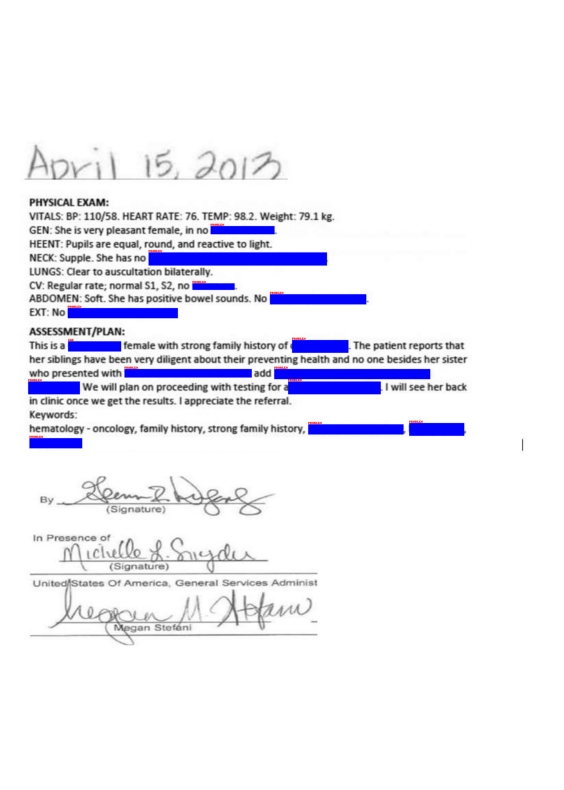

In [10]:
# Colored Band with labels

path='content/*.pdf'
box = "colored_box"

ocr_entity_processor(spark=spark,
                    file_path = path,
                    ner_pipeline = nlp_model,
                    chunk_col = "merged_chunk",
                    style = box,
                    save_dir = "colored_box",
                    box_color = (0, 0, 255),
                    label= True,
                    label_color = "red",
                    display_result = True)

OCR pipeline is running...
Drawing colored box...
Saving started...
File saved to colored_box/MT_OCR_HW_01_colored_box.pdf successfully.


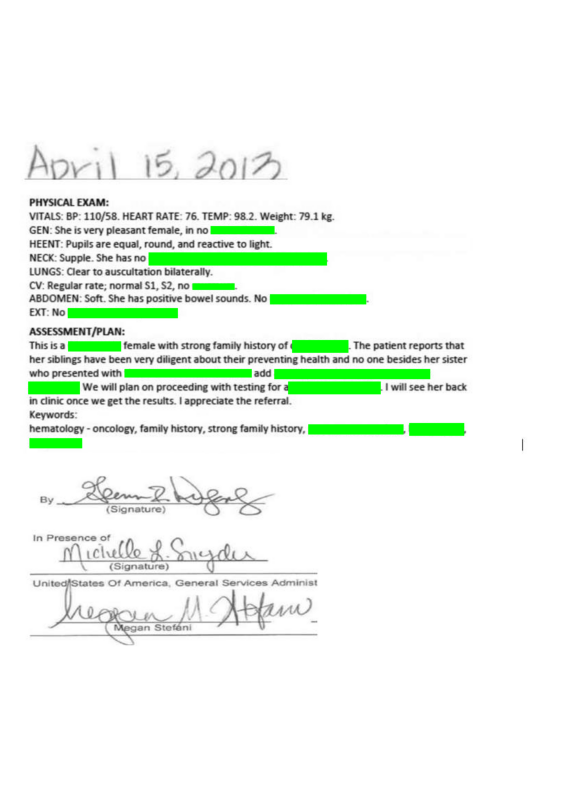

In [11]:
# Colored Band without labels

path='content/*.pdf'
box = "colored_box"

ocr_entity_processor(spark=spark,
                    file_path=path,
                    ner_pipeline = nlp_model,
                    chunk_col = "merged_chunk",
                    style = box,
                    save_dir = "colored_box",
                    box_color = (0, 255, 0),
                    label= False,
                    label_color = "red",
                    display_result = True)

OCR pipeline is running...
Drawing colored box...
Saving started...
File saved to colored_box/MT_OCR_HW_01_colored_box.pdf successfully.


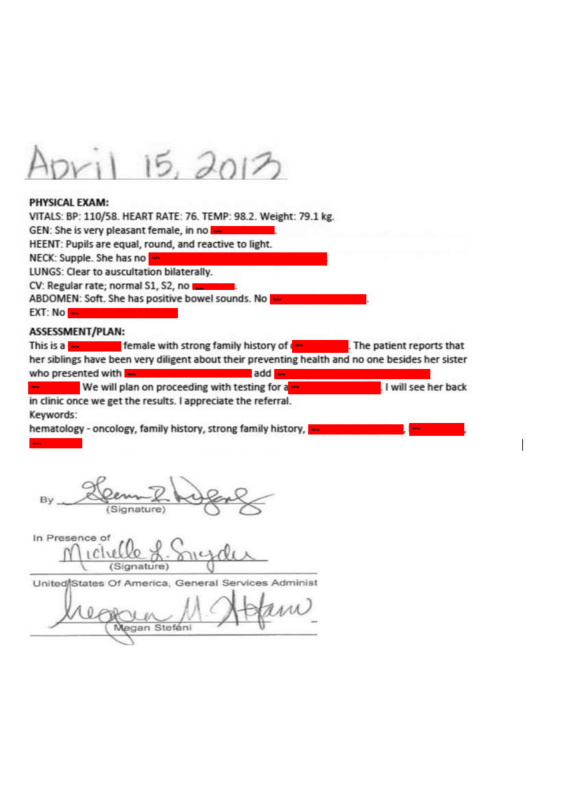

In [12]:
# Colored Band with text band parameter

path='content/*.pdf'
box = "colored_box"

ocr_entity_processor(spark=spark,
                    file_path = path,
                    ner_pipeline = nlp_model,
                    chunk_col = "merged_chunk",
                    style = box,
                    save_dir = "colored_box",
                    box_color = (255, 0, 0),
                    display_result = True ,
                    text_band="data")   ## Default None (without)

image_handwritten_detector_gsa0803 download started this may take some time.
Approximate size to download 244.5 MB
OCR pipeline is running...
Drawing colored box...
Saving started...
File saved to colored_box/MT_OCR_HW_01_colored_box.pdf successfully.


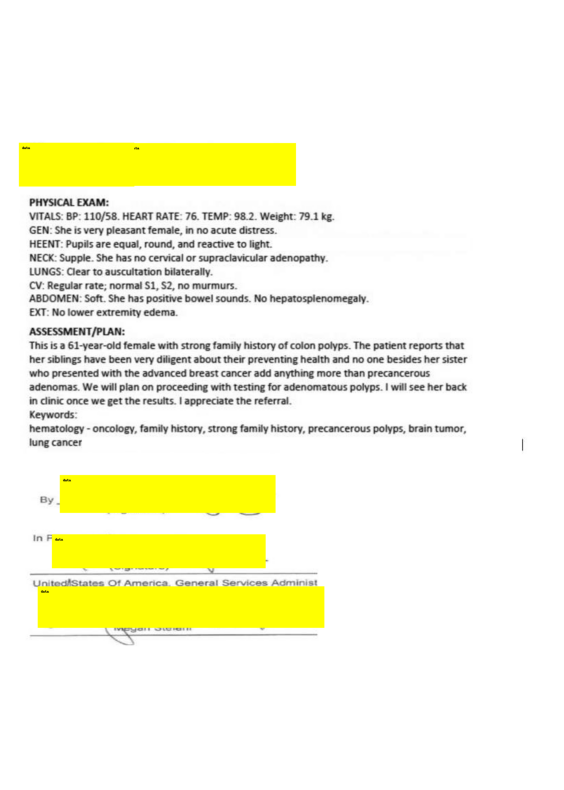

In [13]:
# Colored Band with text band and text type parameters
# Handling just handwritten text

path='content/*.pdf'
box = "colored_box"

ocr_entity_processor(spark=spark,
                    file_path = path,
                    ner_pipeline = nlp_model,
                    chunk_col = "merged_chunk",
                    style = box,
                    save_dir = "colored_box",
                    box_color = (255, 255, 0),
                    display_result = True ,
                    text_band="data",
                    text_type = "handwritten")    ## Default = "printed"

image_handwritten_detector_gsa0803 download started this may take some time.
Approximate size to download 244.5 MB
OCR pipeline is running...
Drawing colored box...
Saving started...
File saved to colored_box/MT_OCR_HW_01_colored_box.pdf successfully.


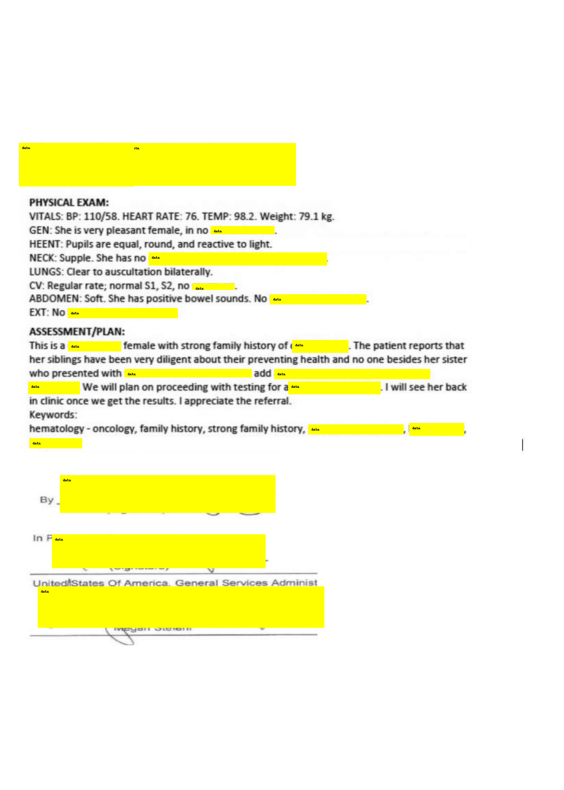

In [14]:
# Colored Band with text band and text type parameters
# Handling both handwritten and printed text at the same time

path='content/*.pdf'
box = "colored_box"

ocr_entity_processor(spark=spark,
                    file_path = path,
                    ner_pipeline = nlp_model,
                    chunk_col = "merged_chunk",
                    style = box,
                    save_dir = "colored_box",
                    box_color = (255, 255, 0),
                    display_result = True ,
                    text_band="data",
                    text_type = "both")    ## Default = "printed"

### Boundig Box

OCR pipeline is running...
Drawing bounding box...
Saving started...
File saved to bounding_box/MT_OCR_HW_01_bounding_box.pdf successfully.
Color chart of the entity labels is saved to label_colors.png.


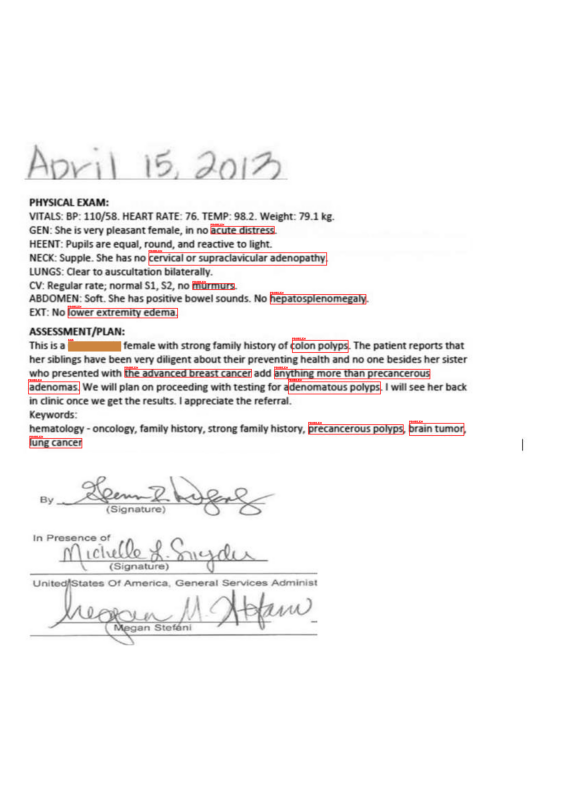

In [15]:
# Bounding Box with labels and black list

path='content/*.pdf'
box = "bounding_box"

ocr_entity_processor(spark=spark,
                     file_path=path,
                    ner_pipeline = nlp_model,
                    chunk_col = "merged_chunk",
                    black_list = ["AGE", "DAte", "PATIENT"],
                    style = box,
                    save_dir = "bounding_box",
                    label= True,
                    label_color = "red",
                    color_chart_path = "label_colors.png",
                    display_result=True)

In [16]:
# Bounding Box without display

path='content/*.pdf'
box = "bounding_box"

ocr_entity_processor(spark=spark,
                     file_path=path,
                    ner_pipeline = nlp_model,
                    chunk_col = "merged_chunk",
                    black_list = ["AGE", "DAte", "PATIENT"],
                    style = box,
                    save_dir = "bounding_box",
                    label= True,
                    label_color = "red",
                    color_chart_path = "label_colors.png",
                    display_result=False)

OCR pipeline is running...
Drawing bounding box...
Saving started...
File saved to bounding_box/MT_OCR_HW_01_bounding_box.pdf successfully.
Color chart of the entity labels is saved to label_colors.png.


OCR pipeline is running...
Drawing bounding box...
Saving started...
File saved to bounding_box/MT_OCR_HW_01_bounding_box.pdf successfully.
Color chart of the entity labels is saved to label_colors.png.


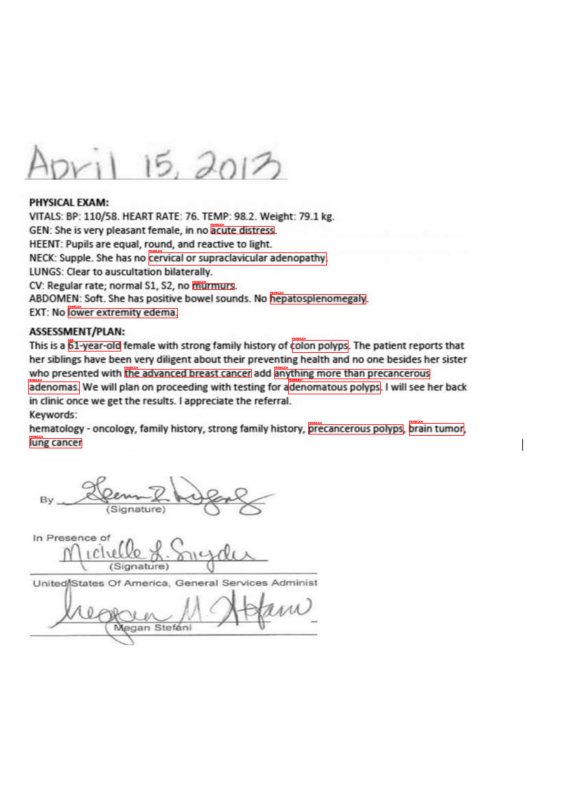

In [17]:
# Bounding Box without black list

path='content/*.pdf'
box = "bounding_box"

ocr_entity_processor(spark=spark,
                     file_path=path,
                    ner_pipeline = nlp_model,
                    chunk_col = "merged_chunk",
                    style = box,
                    save_dir = "bounding_box",
                    label= True,
                    label_color = "red",
                    color_chart_path = "label_colors.png",
                    display_result=True)

OCR pipeline is running...
Drawing bounding box...
Saving started...
File saved to bounding_box/MT_OCR_HW_01_bounding_box.pdf successfully.
Color chart of the entity labels is saved to color_chart.png.


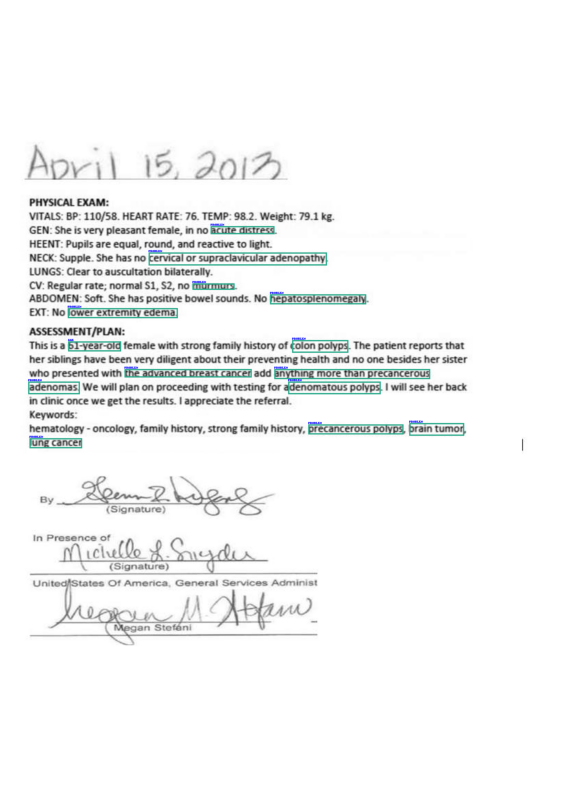

In [18]:
# Bounding Box with adjusting outline width and outline color

path='content/*.pdf'
box = "bounding_box"

ocr_entity_processor(spark=spark,
                    file_path = path,
                    ner_pipeline = nlp_model,
                    chunk_col = "merged_chunk",
                    style = box,
                    save_dir = "bounding_box",
                    label= True,
                    label_color = "blue",
                    display_result = True ,
                    outline_width = 4,                     ## Default = 2
                    outline_color = (42, 170, 138))        ## Takes RGB tuples (42, 170, 138) : Jungle Gree)

image_handwritten_detector_gsa0803 download started this may take some time.
Approximate size to download 244.5 MB
OCR pipeline is running...
Drawing bounding box...
Saving started...
File saved to bounding_box/MT_OCR_HW_01_bounding_box.pdf successfully.
Color chart of the entity labels is saved to color_chart.png.


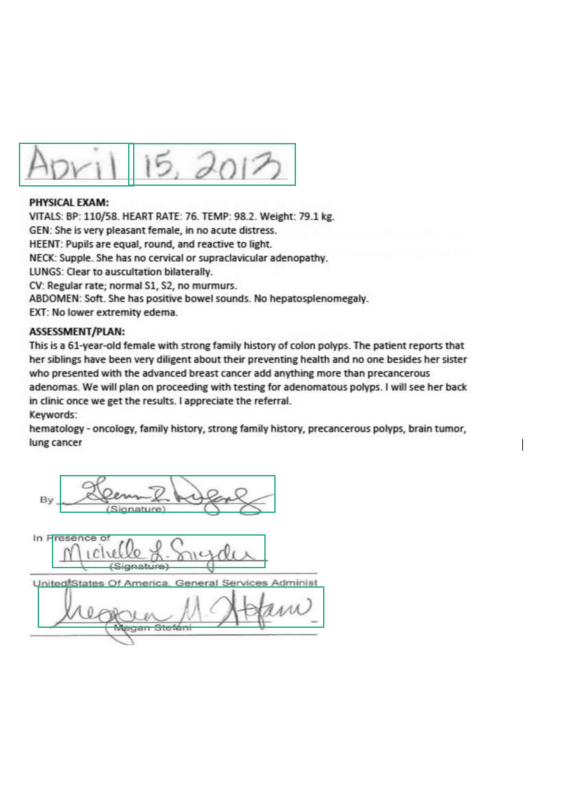

In [19]:
# Bounding Box with text type parameter
# Handling just handwritten text

path='content/*.pdf'
box = "bounding_box"

ocr_entity_processor(spark=spark,
                    file_path = path,
                    ner_pipeline = nlp_model,
                    chunk_col = "merged_chunk",
                    style = box,
                    save_dir = "bounding_box",
                    label= False,
                    display_result = True ,
                    outline_width = 4,
                    outline_color = (42, 170, 138),
                    text_type = "handwritten")    ## Default = "printed"


image_handwritten_detector_gsa0803 download started this may take some time.
Approximate size to download 244.5 MB
OCR pipeline is running...
Drawing bounding box...
Saving started...
File saved to bounding_box/MT_OCR_HW_01_bounding_box.pdf successfully.
Color chart of the entity labels is saved to color_chart.png.


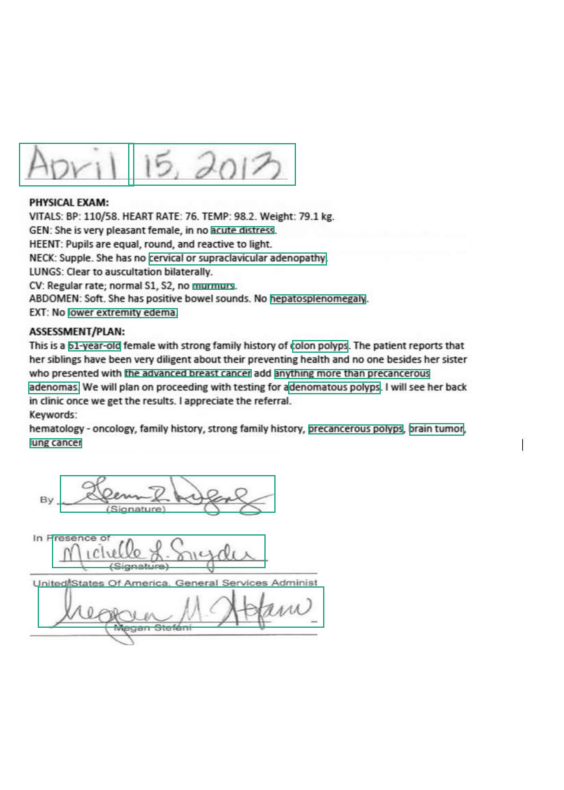

In [20]:
# Bounding Box with text type parameter
# Handling both handwritten and printed text at the same time

path='content/*.pdf'
box = "bounding_box"

ocr_entity_processor(spark=spark,
                    file_path = path,
                    ner_pipeline = nlp_model,
                    chunk_col = "merged_chunk",
                    style = box,
                    save_dir = "bounding_box",
                    label= False,
                    display_result = True ,
                    outline_width = 4,
                    outline_color = (42, 170, 138),
                    text_type = "both")    ## Default = "printed"


### Highlighted Box

OCR pipeline is running...
Highlighting...
Saving started...
File saved to highlight/MT_OCR_HW_01_highlight.pdf successfully.
Color chart of the entity labels is saved to label_colors.png.


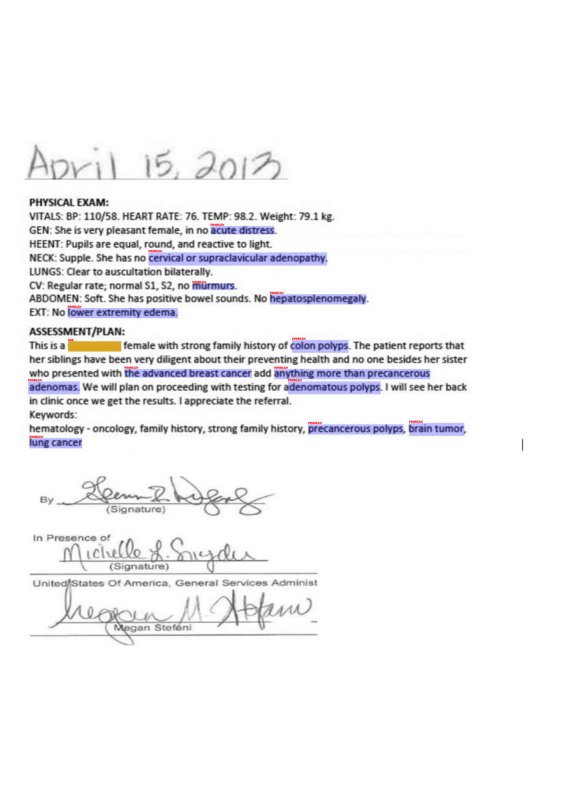

In [21]:
# Highlight with labels and black_list

path='content/*.pdf'
box = "highlight"

ocr_entity_processor(spark=spark,
                     file_path=path,
                    ner_pipeline = nlp_model,
                    chunk_col = "merged_chunk",
                    black_list = ["AGE", "DATE", "PATIENT"],
                    style = box,
                    save_dir = "highlight",
                    label= True,
                    label_color = "red",
                    color_chart_path = "label_colors.png",
                    display_result=True)

OCR pipeline is running...
Highlighting...
Saving started...
File saved to highlight/MT_OCR_HW_01_highlight.pdf successfully.
Color chart of the entity labels is saved to label_colors.png.


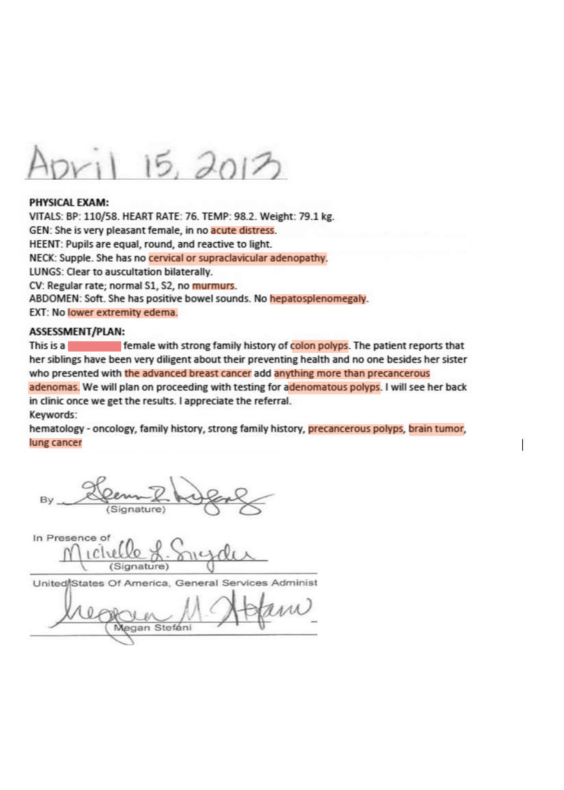

In [22]:
# Highlight without labels and with black_list

path='content/*.pdf'
box = "highlight"

ocr_entity_processor(spark=spark,
                     file_path=path,
                    ner_pipeline = nlp_model,
                    chunk_col = "merged_chunk",
                    black_list = ["AGE", "DAte", "PATIENT"],
                    style = box,
                    save_dir = "highlight",
                    label= False,
                    label_color = "red",
                    color_chart_path = "label_colors.png",
                    display_result=True)

In [23]:
# Highlight without display

path='content/*.pdf'
box = "highlight"

ocr_entity_processor(spark=spark,
                     file_path=path,
                    ner_pipeline = nlp_model,
                    chunk_col = "merged_chunk",
                    black_list = ["AGE", "DAte", "PATIENT"],
                    style = box,
                    save_dir = "highlight",
                    label= True,
                    label_color = "red",
                    color_chart_path = "label_colors.png",
                    display_result=False)

OCR pipeline is running...
Highlighting...
Saving started...
File saved to highlight/MT_OCR_HW_01_highlight.pdf successfully.
Color chart of the entity labels is saved to label_colors.png.


OCR pipeline is running...
Highlighting...
Saving started...
File saved to highlight/MT_OCR_HW_01_highlight.pdf successfully.
Color chart of the entity labels is saved to label_colors.png.


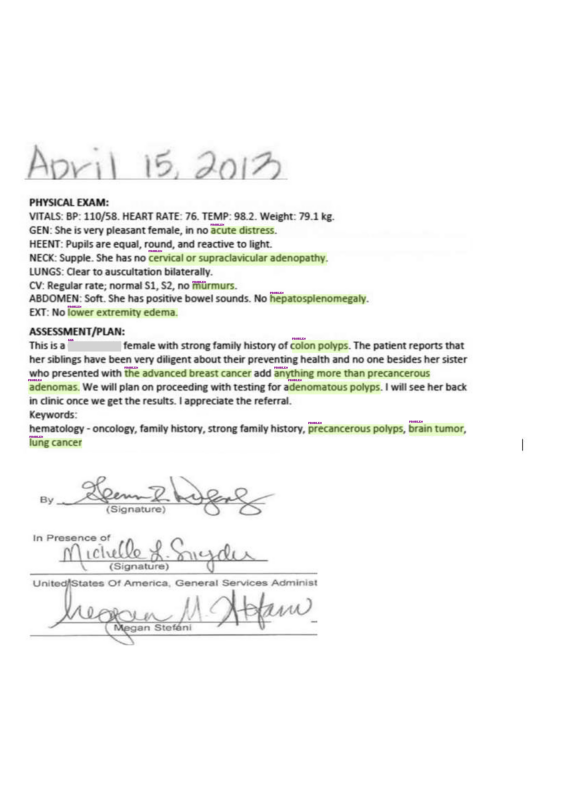

In [24]:
# Highlight change label color

path='content/*.pdf'
box = "highlight"

ocr_entity_processor(spark=spark,
                     file_path=path,
                    ner_pipeline = nlp_model,
                    chunk_col = "merged_chunk",
                    black_list = ["AGE", "DAte", "PATIENT"],
                    style = box,
                    save_dir = "highlight",
                    label= True,
                    label_color = "purple",
                    color_chart_path = "label_colors.png",
                    display_result=True)

image_handwritten_detector_gsa0803 download started this may take some time.
Approximate size to download 244.5 MB
OCR pipeline is running...
Highlighting...
Saving started...
File saved to highlight/MT_OCR_HW_01_highlight.pdf successfully.
Color chart of the entity labels is saved to label_colors.png.


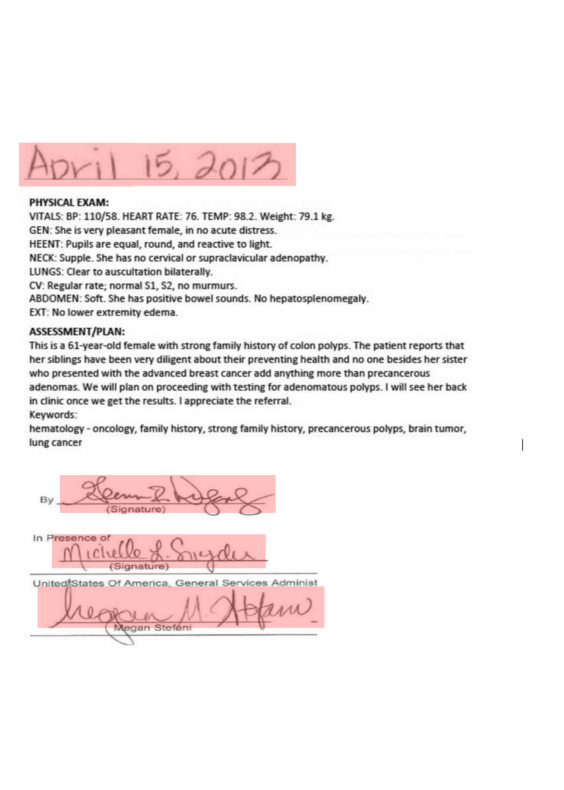

In [25]:
# Highlight with text type parameter
# Handling just handwritten text

path='content/*.pdf'
box = "highlight"

ocr_entity_processor(spark=spark,
                     file_path=path,
                    ner_pipeline = nlp_model,
                    chunk_col = "merged_chunk",
                    style = box,
                    save_dir = "highlight",
                    label= False,
                    color_chart_path = "label_colors.png",
                    display_result=True,
                    text_type = "handwritten")    ## Default = "printed"

image_handwritten_detector_gsa0803 download started this may take some time.
Approximate size to download 244.5 MB
OCR pipeline is running...
Highlighting...
Saving started...
File saved to highlight/MT_OCR_HW_01_highlight.pdf successfully.
Color chart of the entity labels is saved to label_colors.png.


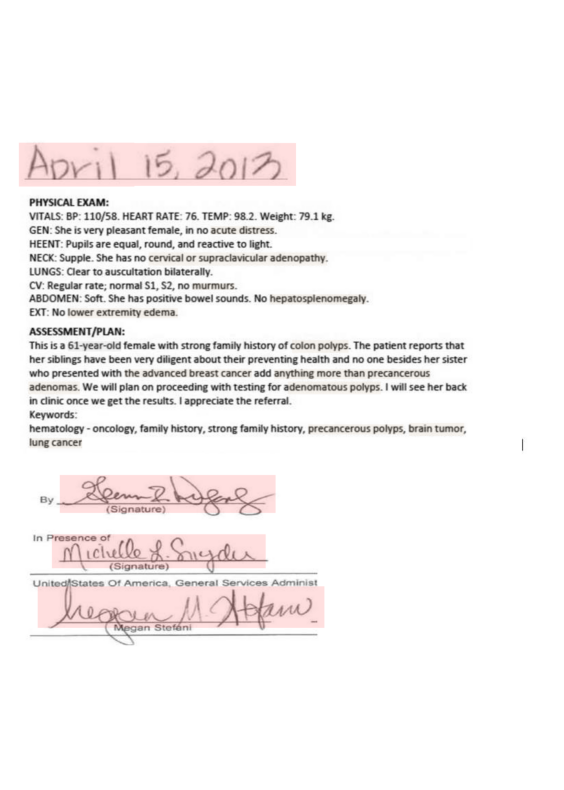

In [26]:
# Highlight with text type parameter
# Handling both handwritten and printed text at the same time

path='content/*.pdf'
box = "highlight"

ocr_entity_processor(spark=spark,
                     file_path=path,
                    ner_pipeline = nlp_model,
                    chunk_col = "merged_chunk",
                    style = box,
                    save_dir = "highlight",
                    label= False,
                    color_chart_path = "label_colors.png",
                    display_result=True,
                    text_type = "both")    ## Default = "printed"
